# Clustering des journées CO2 par encodage en paliers — OQAI CNL1

Approche alternative au clustering sur signal continu : chaque journée est
d'abord **discrétisée** en une séquence de paliers qualitatifs
(*forte baisse → baisse → stable → hausse → forte hausse*), puis les
séquences ainsi obtenues sont regroupées.

L'intérêt est double : les séquences de paliers sont **directement lisibles**
(une journée devient une suite d'états nommés) et le clustering porte sur la
succession de ces états plutôt que sur des valeurs numériques.

**Point central de ce notebook** : les seuils qui définissent les paliers ne
sont pas choisis arbitrairement — ils sont **dérivés de la distribution
observée** des valeurs, étudiée en section 3.

**Démarche :**
1. Chargement et préparation du signal CO2 (dérivée lissée)
2. Normalisation par journée
3. Étude de la distribution des valeurs → définition des seuils
4. Encodage en paliers
5. Clustering des séquences de paliers
6. Interprétation et caractérisation


## 1. Configuration et chargement


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans
from tslearn.clustering import TimeSeriesKMeans

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60)

DATA = '../data/cln1/Raw'

# Lissage Savitzky-Golay : fenêtre de 13 points (10 min chacun ≈ 2h10) + polynôme d'ordre 2.
SG_WINDOW = 13
SG_POLY   = 2

# Grille horaire commune : 144 tranches de 10 min → heures décimales (0 à 24)
hours = np.arange(144) / 6


In [2]:
# Série CO2 continue (toutes les mesures, tous les logements)
co2 = pd.read_csv(f'{DATA}/Mesures_Confort_Dynamique/CNL1_SERIE_CO2.txt',
                  sep='\t', encoding='latin1',
                  usecols=['CODELIEU', 'DATE_HEURE', 'VALEUR'],
                  parse_dates=['DATE_HEURE'])
co2['VALEUR'] = pd.to_numeric(co2['VALEUR'], errors='coerce')
co2 = co2.dropna(subset=['VALEUR'])
co2['DATE'] = co2['DATE_HEURE'].dt.normalize()

# Type de ventilation par logement (variable de validation, indépendante du signal)
KVNT_LABELS = {1: 'VMC', 2: 'Extracteurs', 3: 'Naturelle', 4: 'Aucune'}
ventilation = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                          sep=';', encoding='latin1', usecols=['CODELIEU', 'KVNT'])
ventilation['KVNT'] = pd.to_numeric(ventilation['KVNT'], errors='coerce')
ventilation = ventilation.assign(
    aeration=lambda d: d['KVNT'].map(KVNT_LABELS)).set_index('CODELIEU')['aeration']

print(f'{len(co2):,} mesures — {co2["CODELIEU"].nunique()} logements')
print(f'Période : {co2["DATE"].min().date()} → {co2["DATE"].max().date()}')


514,425 mesures — 535 logements
Période : 2003-10-01 → 2005-12-21


## 2. Préparation du signal — dérivée normalisée par journée

On travaille sur la **dérivée** du CO2 (vitesse de variation), qui traduit les
événements d'occupation, plutôt que sur son niveau absolu.

Deux précautions :

- **La dérivée est calculée sur la série continue** de chaque logement, avant
  découpage en journées : le filtre Savitzky-Golay a besoin de points de part
  et d'autre de chaque instant, et un calcul journée par journée créerait un
  artefact à minuit.
- **La normalisation se fait ensuite, journée par journée** (z-score sur les
  144 points de la journée). Les logements ont des amplitudes de variation très
  différentes — un même seuil en ppm/h n'a pas le même sens de l'un à l'autre.
  Cette normalisation est indispensable pour que des seuils de paliers
  **communs** aient un sens.


In [3]:
# Dérivée Savitzky-Golay sur la série CONTINUE de chaque logement (ppm/h)
co2_t = co2.sort_values(['CODELIEU', 'DATE_HEURE']).copy()
co2_t['deriv'] = (co2_t.groupby('CODELIEU')['VALEUR']
                  .transform(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY,
                                                     deriv=1, delta=1/6)))

# Journées complètes uniquement (exactement 144 mesures de 10 min)
n = co2_t.groupby(['CODELIEU', 'DATE'])['VALEUR'].transform('size')
co2_t = co2_t[n == 144]
co2_t['rang'] = co2_t.groupby(['CODELIEU', 'DATE']).cumcount()

piv_deriv = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='deriv')
piv_co2   = co2_t.pivot(index=['CODELIEU', 'DATE'], columns='rang', values='VALEUR')

# Exclusion des journées saturées (>= 6000 ppm : plage de mesure dépassée)
satures = piv_co2.index[(piv_co2.values >= 6000).any(axis=1)]
piv_deriv = piv_deriv.drop(satures)
piv_co2   = piv_co2.loc[piv_deriv.index]

deriv_brute = piv_deriv.values   # (n_journées, 144) en ppm/h
co2_brut    = piv_co2.values     # (n_journées, 144) en ppm

meta = piv_deriv.index.to_frame(index=False)
meta['we'] = meta['DATE'].dt.dayofweek >= 5

# Normalisation par journée (z-score sur les 144 points de chaque journée)
mu_day  = deriv_brute.mean(axis=1, keepdims=True)
sig_day = deriv_brute.std(axis=1, keepdims=True)
D = (deriv_brute - mu_day) / np.clip(sig_day, 1e-9, None)

print(f'{len(satures)} journées saturées exclues')
print(f'{len(meta):,} journées retenues — {meta["CODELIEU"].nunique()} logements')
print(f'D : {D.shape} — dérivée normalisée par journée')


14 journées saturées exclues
2,998 journées retenues — 513 logements
D : (2998, 144) — dérivée normalisée par journée


## 3. De la distribution des valeurs aux seuils des paliers

Les seuils qui séparent les paliers doivent être **lus dans les données**, pas
posés arbitrairement. On procède en trois temps :

1. **Observer la distribution** des valeurs de dérivée, pour connaître sa forme
   (concentration, symétrie, queues).
2. **Lisser avant de discrétiser** : sans cela, le bruit résiduel fait osciller
   le signal autour d'un seuil et l'encodage alterne sans arrêt entre deux
   paliers voisins, ce qui produit des séquences illisibles.
3. **Fixer les seuils par quantiles** calculés **sur le signal lissé**, de sorte
   que chaque palier corresponde à une fraction connue des observations.


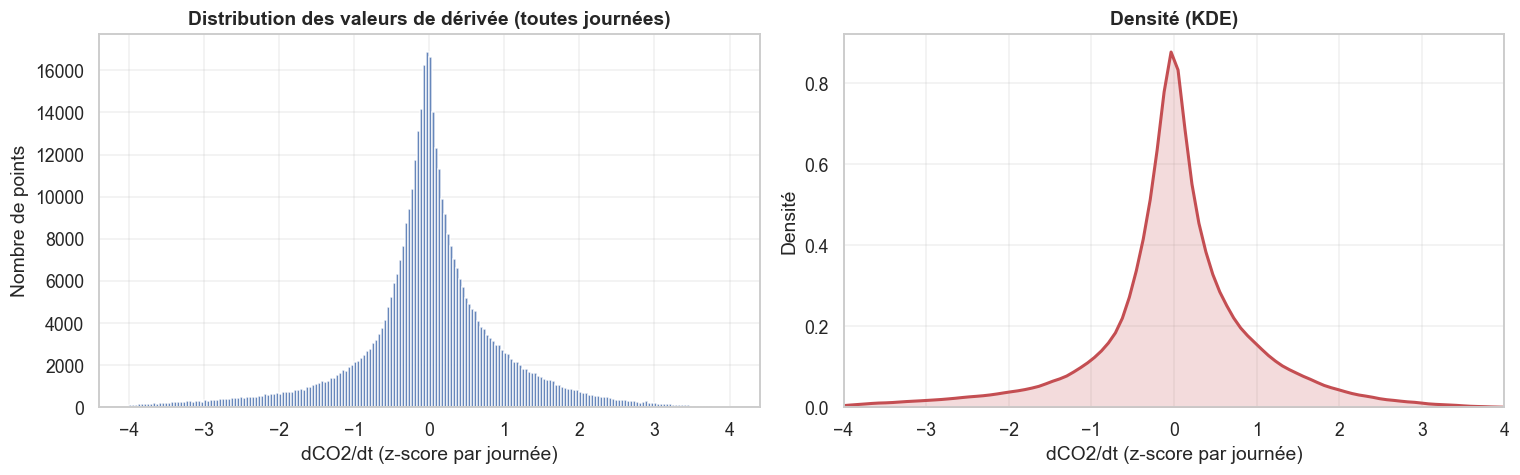

Percentiles (1, 5, 10, 25, 50, 75, 90, 95, 99) : [-3.21 -1.78 -1.07 -0.36 -0.    0.43  1.12  1.64  2.72]
Asymétrie : -0.33 | Aplatissement : 2.77
Part des points dans [-0.2, 0.2] : 31.6%


In [4]:
# ── Étape 1 : observer la distribution des valeurs
vals = D.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(vals, bins=200, range=(-4, 4), color='#4C72B0', alpha=0.85)
axes[0].set_title('Distribution des valeurs de dérivée (toutes journées)', fontweight='bold')
axes[0].set_xlabel('dCO2/dt (z-score par journée)'); axes[0].set_ylabel('Nombre de points')
axes[0].grid(True, alpha=0.3)

sns.kdeplot(vals, ax=axes[1], color='#C44E52', lw=2, fill=True, alpha=0.2)
axes[1].set_title('Densité (KDE)', fontweight='bold')
axes[1].set_xlabel('dCO2/dt (z-score par journée)'); axes[1].set_ylabel('Densité')
axes[1].set_xlim(-4, 4); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

q = np.percentile(vals, [1, 5, 10, 25, 50, 75, 90, 95, 99])
print('Percentiles (1, 5, 10, 25, 50, 75, 90, 95, 99) :', q.round(2))
print(f'Asymétrie : {pd.Series(vals).skew():.2f} | Aplatissement : {pd.Series(vals).kurt():.2f}')
print(f'Part des points dans [-0.2, 0.2] : {100*((vals >= -0.2) & (vals <= 0.2)).mean():.1f}%')


**Lecture de la distribution** — la distribution est **unimodale**, centrée sur
zéro et symétrique, avec un pic très marqué au centre et des queues épaisses
(aplatissement nettement supérieur à celui d'une loi normale). Une grande part
des points se concentre près de zéro : la plupart du temps, dans la plupart des
journées, le CO2 varie peu.

Deux conséquences pour la construction des paliers :

- **Aucune séparation naturelle** n'existe dans les données (pas de second mode,
  pas de creux) : il n'y a pas de frontière « évidente » à détecter, les seuils
  relèvent donc d'un choix explicite à documenter.
- **Le pic central impose de lisser** : avec autant de points serrés autour de
  zéro, le moindre bruit traverse un seuil placé dans cette zone. D'où l'étape
  de lissage ci-dessous, avant toute discrétisation.


Changements de signe par journée — avant lissage : 8.2 | après : 7.5


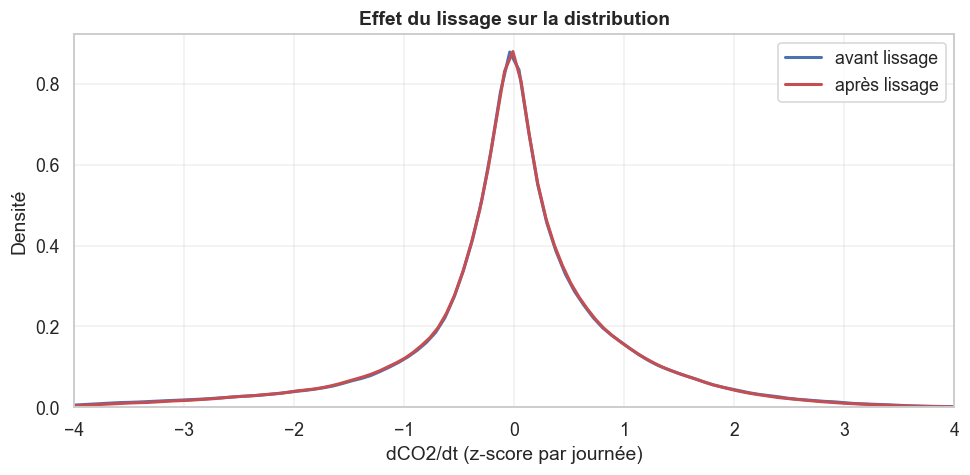

In [5]:
# ── Étape 2 : lisser avant de discrétiser
# Second passage du même filtre Savitzky-Golay, cette fois en lissage simple
# (deriv=0), appliqué journée par journée. Objectif : retirer le bruit haute
# fréquence qui ferait basculer l'encodage d'un palier à l'autre sans raison.
D_lisse = np.apply_along_axis(lambda x: savgol_filter(x, SG_WINDOW, SG_POLY), 1, D)

# Effet du lissage : nombre de changements de signe par journée (proxy du bruit)
chg_avant = (np.diff(np.sign(D), axis=1) != 0).sum(axis=1)
chg_apres = (np.diff(np.sign(D_lisse), axis=1) != 0).sum(axis=1)
print(f'Changements de signe par journée — avant lissage : {chg_avant.mean():.1f} '
      f'| après : {chg_apres.mean():.1f}')

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.kdeplot(D.ravel(), ax=ax, lw=2, label='avant lissage', color='#4C72B0')
sns.kdeplot(D_lisse.ravel(), ax=ax, lw=2, label='après lissage', color='#C44E52')
ax.set_xlim(-4, 4); ax.set_xlabel('dCO2/dt (z-score par journée)'); ax.set_ylabel('Densité')
ax.set_title('Effet du lissage sur la distribution', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


Seuils retenus (z-score) : [-1.066 -0.261  0.299  1.107]

Paliers correspondants :
  0 · forte baisse  [-∞ , -1.07[
  1 · baisse        [-1.07 , -0.26[
  2 · stable        [-0.26 , +0.30[
  3 · hausse        [+0.30 , +1.11[
  4 · forte hausse  [+1.11 , +∞[


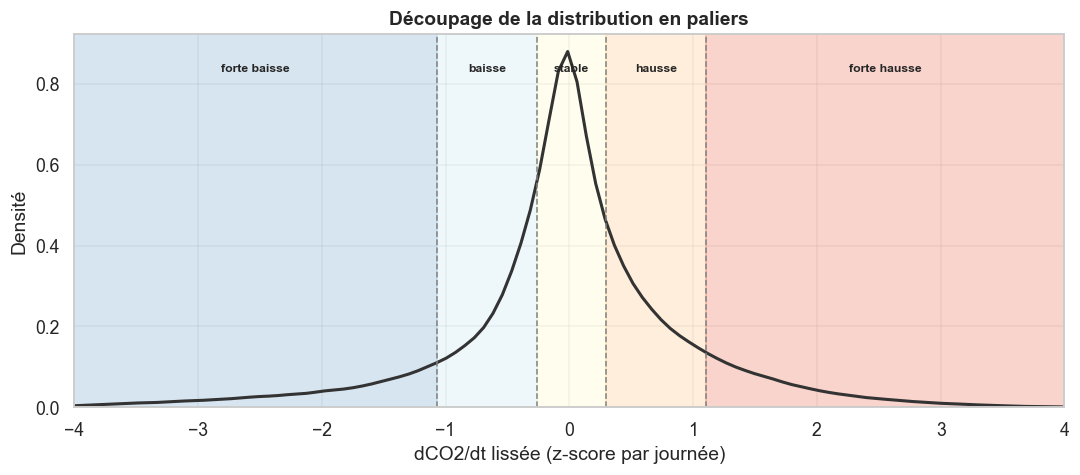

In [6]:
# ── Étape 3 : fixer les seuils par quantiles, sur le signal LISSÉ
# Découpage asymétrique : les paliers extrêmes ("forte baisse" / "forte hausse")
# ne retiennent que les 10 % les plus marqués de chaque côté, et le palier
# "stable" couvre les 40 % centraux. Un découpage en cinq parts égales (20 %
# chacune) rendrait les seuils extrêmes trop proches de zéro : des variations
# ordinaires seraient alors étiquetées "forte", ce qui viderait le terme de sens.
PALIER_NOMS = ['forte baisse', 'baisse', 'stable', 'hausse', 'forte hausse']
QUANTILES   = [0.10, 0.30, 0.70, 0.90]
N_PALIERS   = len(PALIER_NOMS)

seuils = np.quantile(D_lisse.ravel(), QUANTILES)
print('Seuils retenus (z-score) :', seuils.round(3))
print('\nPaliers correspondants :')
bornes = [-np.inf, *seuils, np.inf]
for i, nom in enumerate(PALIER_NOMS):
    b0 = f'{bornes[i]:+.2f}' if np.isfinite(bornes[i]) else '-∞'
    b1 = f'{bornes[i+1]:+.2f}' if np.isfinite(bornes[i+1]) else '+∞'
    print(f'  {i} · {nom:<13} [{b0} , {b1}[')

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.kdeplot(D_lisse.ravel(), ax=ax, color='#333333', lw=2)
colors = sns.color_palette('RdYlBu_r', N_PALIERS)
for i in range(N_PALIERS):
    ax.axvspan(max(bornes[i], -4), min(bornes[i+1], 4), color=colors[i], alpha=0.25)
    centre = np.clip((max(bornes[i], -4) + min(bornes[i+1], 4)) / 2, -3.7, 3.7)
    ax.text(centre, ax.get_ylim()[1] * 0.9, PALIER_NOMS[i], ha='center',
            fontsize=8, fontweight='bold')
for s in seuils:
    ax.axvline(s, color='grey', lw=1, ls='--')
ax.set_xlim(-4, 4)
ax.set_xlabel('dCO2/dt lissée (z-score par journée)'); ax.set_ylabel('Densité')
ax.set_title('Découpage de la distribution en paliers', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Encodage des journées en paliers

Chaque journée devient une séquence de 144 entiers (0 = forte baisse …
4 = forte hausse).


In [7]:
P = np.digitize(D_lisse, seuils)   # (n_journées, 144), valeurs 0..4

repartition = (pd.Series(P.ravel()).value_counts(normalize=True)
               .sort_index().mul(100).round(1))
repartition.index = [PALIER_NOMS[i] for i in repartition.index]
print('Répartition des points par palier :')
print(repartition.to_string())

# Stabilité de l'encodage : nombre de changements de palier par journée
transitions = (np.diff(P, axis=1) != 0).sum(axis=1)
print(f'\nChangements de palier par journée — médiane : {np.median(transitions):.0f} '
      f'| moyenne : {transitions.mean():.1f} | max : {transitions.max()}')


Répartition des points par palier :
forte baisse    10.0
baisse          20.0
stable          40.0
hausse          20.0
forte hausse    10.0

Changements de palier par journée — médiane : 18 | moyenne : 18.5 | max : 47


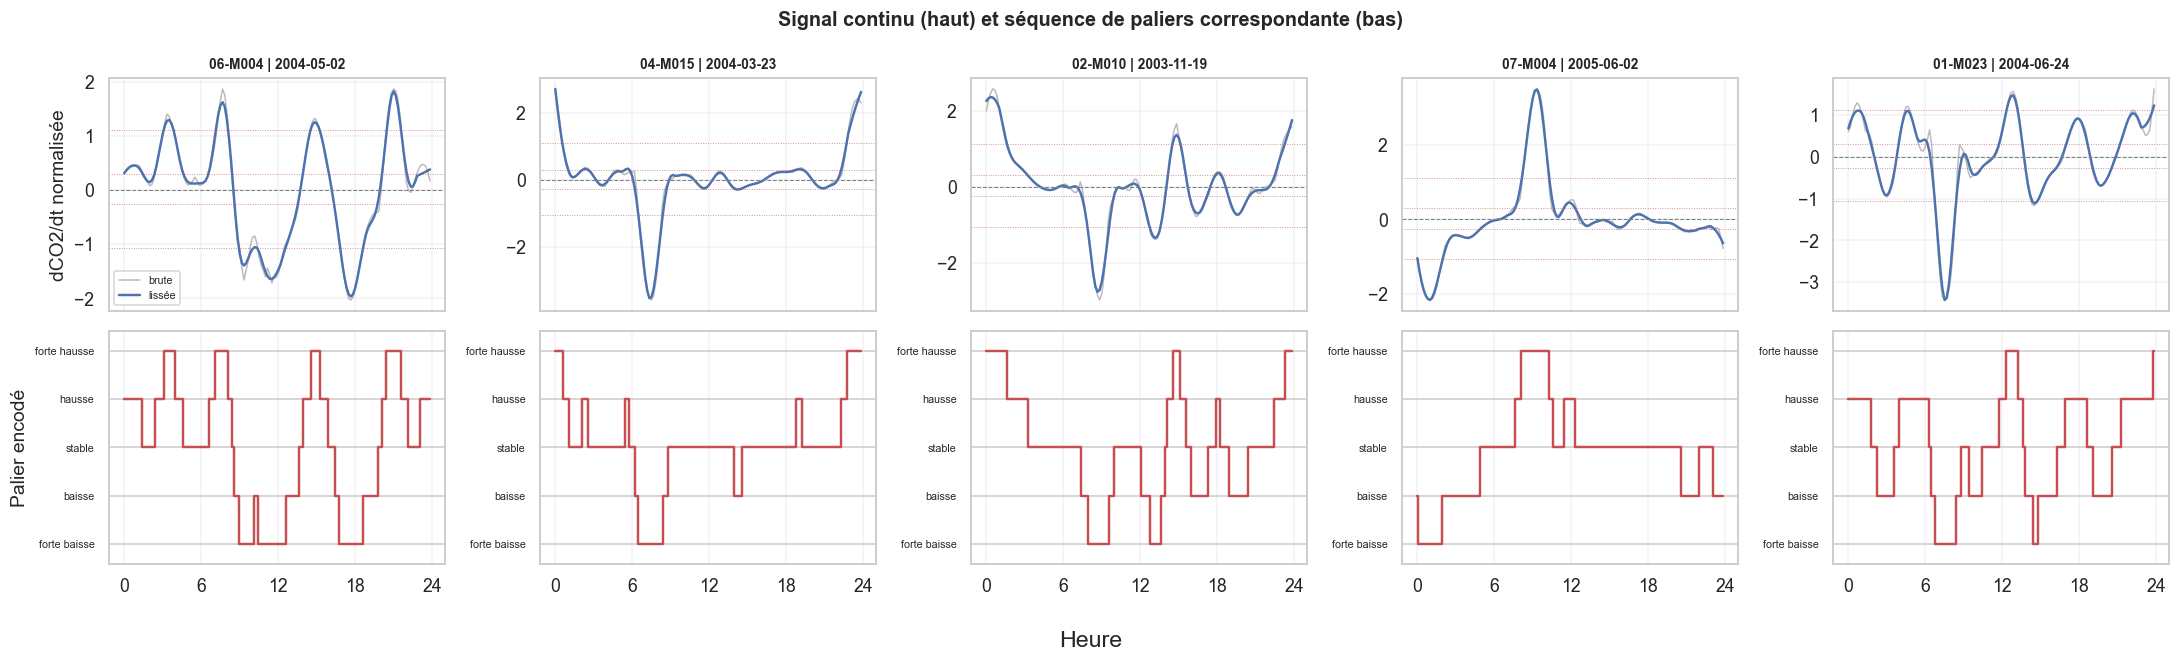

In [8]:
# Contrôle visuel : signal continu vs séquence de paliers, sur 5 journées
rng_ex = np.random.RandomState(42)
idx_ex = rng_ex.choice(len(meta), size=5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(20, 6), sharex=True)

for col, i in enumerate(idx_ex):
    r = meta.iloc[i]

    ax = axes[0, col]
    ax.plot(hours, D[i], lw=1, color='#BBBBBB', label='brute')
    ax.plot(hours, D_lisse[i], lw=1.6, color='#4C72B0', label='lissée')
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    for s in seuils:
        ax.axhline(s, color='#C44E52', lw=0.6, ls=':', alpha=0.7)
    ax.set_title(f"{r['CODELIEU']} | {r['DATE'].date()}", fontsize=9, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.25)
    if col == 0:
        ax.set_ylabel('dCO2/dt normalisée'); ax.legend(fontsize=7)

    ax = axes[1, col]
    ax.step(hours, P[i], where='mid', lw=1.6, color='#C44E52')
    ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=7)
    ax.set_ylim(-0.4, N_PALIERS - 0.6)
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, axis='x', alpha=0.25)
    if col == 0:
        ax.set_ylabel('Palier encodé')

fig.supxlabel('Heure')
plt.suptitle('Signal continu (haut) et séquence de paliers correspondante (bas)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 5. Clustering des séquences de paliers

Deux méthodes sont comparées sur le **même encodage** :

- **DTW** — autorise un décalage temporel borné (±1h) : deux journées avec le
  même enchaînement d'états, décalé d'une demi-heure, sont reconnues proches.
- **K-means euclidien** — compare tranche horaire par tranche horaire, sans
  tolérance au décalage. Beaucoup plus rapide.

Comparer les deux permet de mesurer ce que le réalignement temporel apporte
réellement sur ce jeu de données.


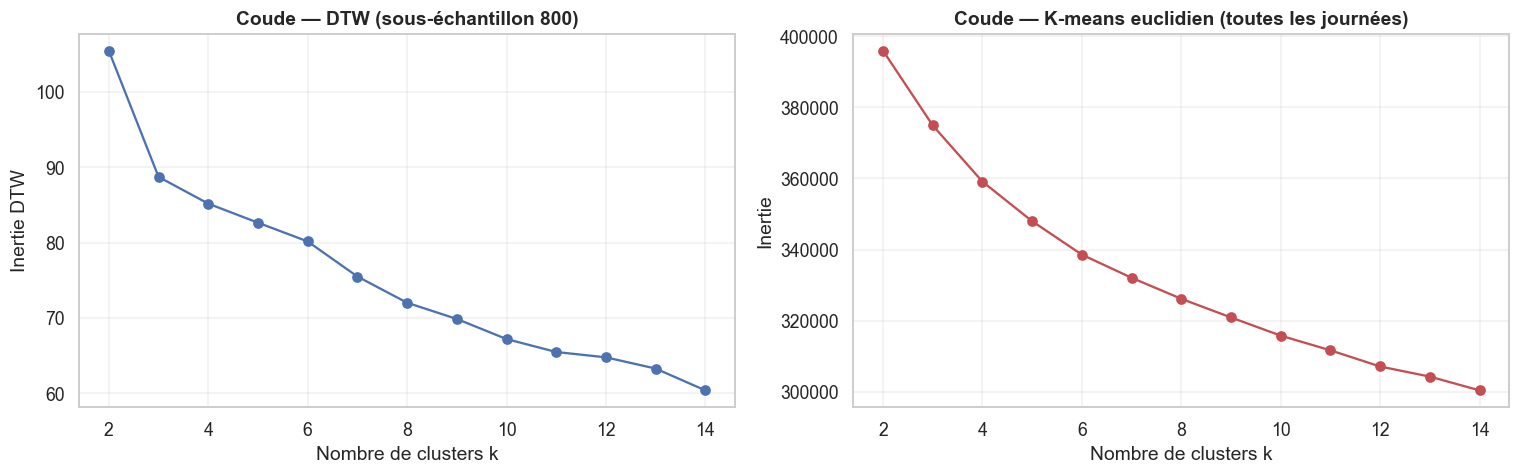

In [9]:
# Choix de K — méthode du coude, pour les deux méthodes.
# Le DTW est évalué sur un sous-échantillon (coût élevé : un clustering complet
# par valeur de k) ; la forme de la courbe suffit à localiser le coude.
SUBSAMPLE_K = 800
rng_k = np.random.RandomState(0)
sub_k = rng_k.choice(len(P), min(SUBSAMPLE_K, len(P)), replace=False)

ks = range(2, 15)
inerties_dtw, inerties_km = [], []
for k in ks:
    m_dtw = TimeSeriesKMeans(n_clusters=k, metric='dtw',
                             metric_params={'global_constraint': 'sakoe_chiba',
                                            'sakoe_chiba_radius': 6},
                             random_state=42, n_jobs=-1)
    m_dtw.fit(P[sub_k][:, :, None].astype(float))
    inerties_dtw.append(m_dtw.inertia_)

    inerties_km.append(KMeans(n_clusters=k, random_state=42, n_init=20)
                       .fit(P.astype(float)).inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(ks), inerties_dtw, marker='o', color='#4C72B0')
axes[0].set_title(f'Coude — DTW (sous-échantillon {SUBSAMPLE_K})', fontweight='bold')
axes[0].set_xlabel('Nombre de clusters k'); axes[0].set_ylabel('Inertie DTW')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(ks), inerties_km, marker='o', color='#C44E52')
axes[1].set_title('Coude — K-means euclidien (toutes les journées)', fontweight='bold')
axes[1].set_xlabel('Nombre de clusters k'); axes[1].set_ylabel('Inertie')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [10]:
# K retenu au vu des coudes ci-dessus (à ajuster après lecture des courbes)
K = 6

model_dtw = TimeSeriesKMeans(
    n_clusters=K, metric='dtw',
    metric_params={'global_constraint': 'sakoe_chiba', 'sakoe_chiba_radius': 6},
    random_state=42, n_jobs=-1, verbose=0,
)
labels_dtw = model_dtw.fit_predict(P[:, :, None].astype(float))

model_km = KMeans(n_clusters=K, random_state=42, n_init=20)
labels_km = model_km.fit_predict(P.astype(float))

meta['cluster_dtw'] = labels_dtw
meta['cluster_km']  = labels_km

from sklearn.metrics import adjusted_rand_score
print(f'K = {K}')
print('\nEffectifs — DTW :')
print(pd.Series(labels_dtw).value_counts().sort_index().to_string())
print('\nEffectifs — K-means :')
print(pd.Series(labels_km).value_counts().sort_index().to_string())
print(f'\nAccord entre les deux partitions (ARI) : '
      f'{adjusted_rand_score(labels_dtw, labels_km):.3f}')


K = 6

Effectifs — DTW :
0    238
1    638
2    528
3    928
4    412
5    254

Effectifs — K-means :
0    603
1    356
2    729
3    356
4    392
5    562

Accord entre les deux partitions (ARI) : 0.208


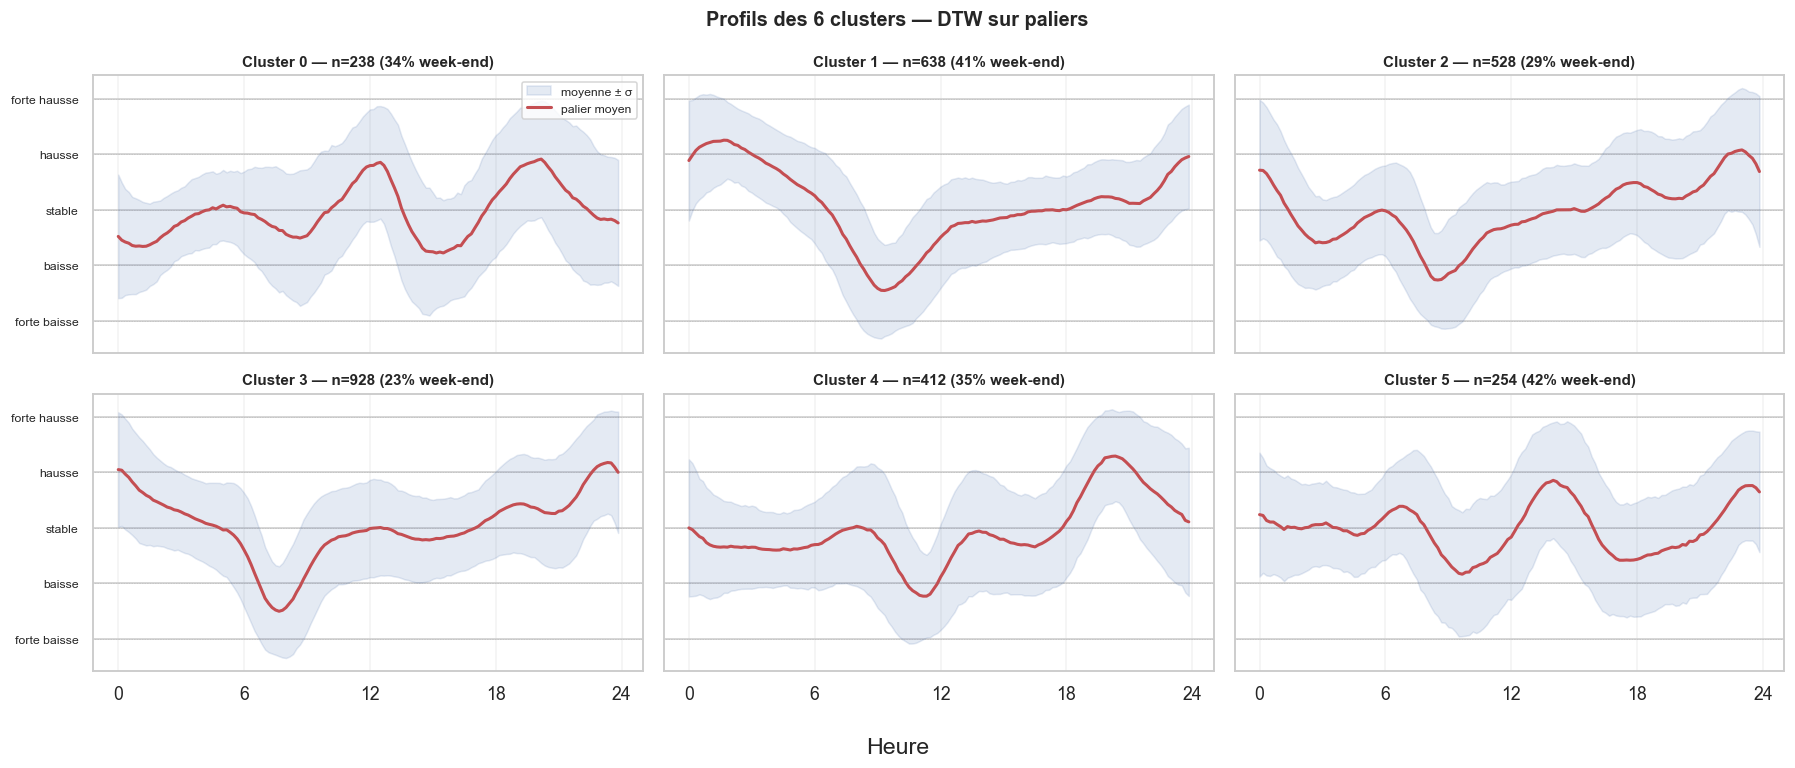

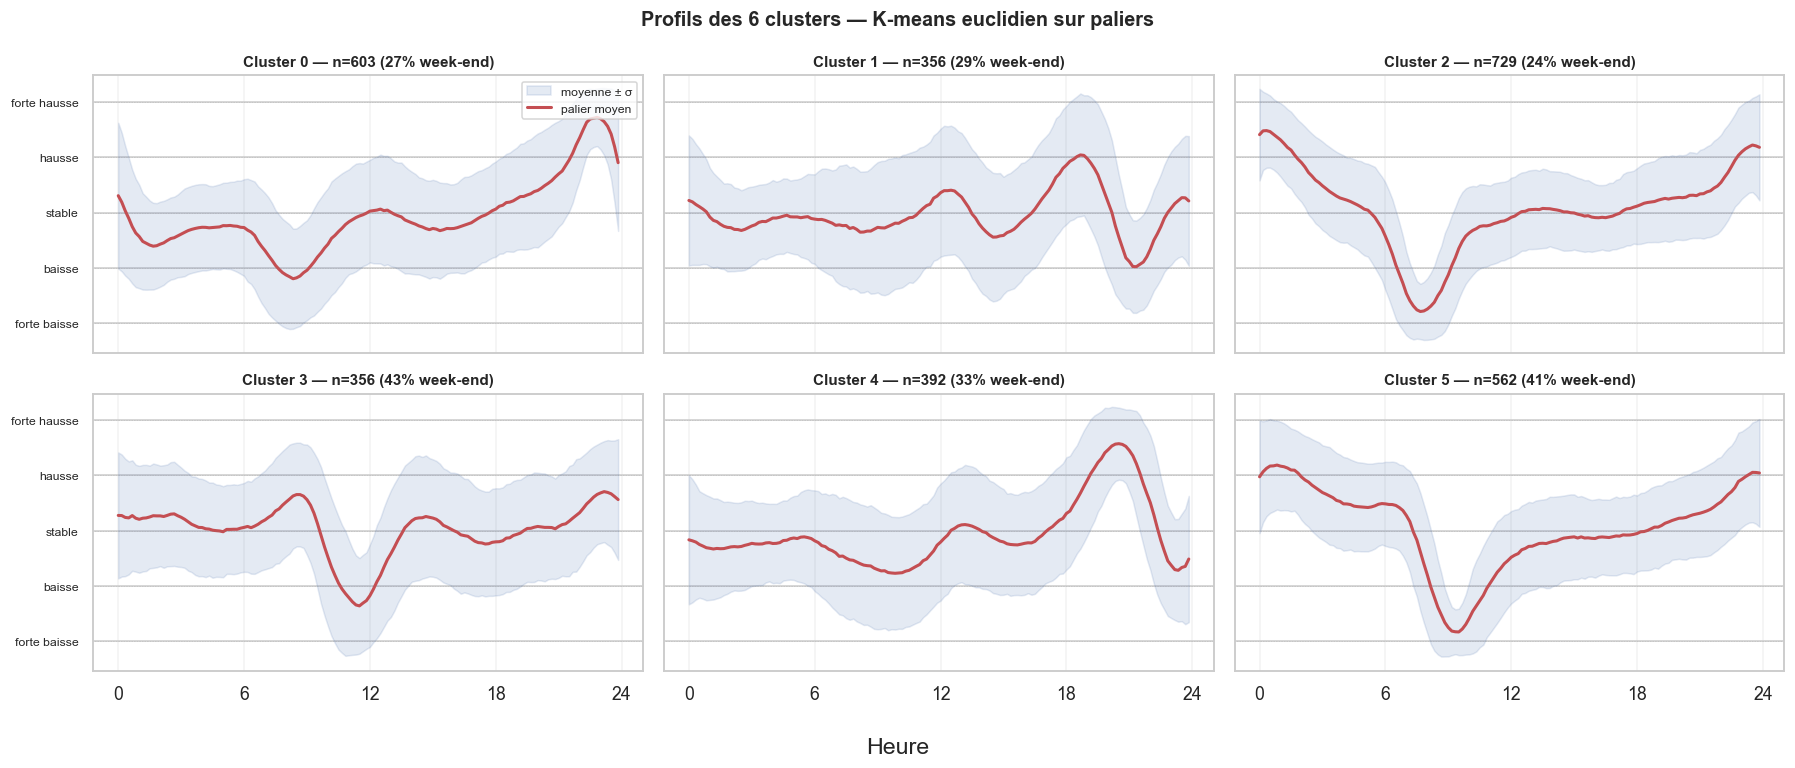

In [11]:
# Profil de chaque cluster : palier moyen ± écart-type au fil de la journée
def profils_clusters(labels, titre):
    n_cols = min(K, 3)
    n_rows = int(np.ceil(K / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for c in range(K):
        ax = axes[c]
        sel = labels == c
        m, s = P[sel].mean(axis=0), P[sel].std(axis=0)
        ax.fill_between(hours, m - s, m + s, alpha=0.15, color='#4C72B0',
                        label='moyenne ± σ')
        ax.plot(hours, m, lw=2, color='#C44E52', label='palier moyen')
        for p in range(N_PALIERS):
            ax.axhline(p, color='grey', lw=0.4, ls=':', alpha=0.5)
        ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=8)
        ax.set_title(f'Cluster {c} — n={sel.sum():,} '
                     f'({meta.loc[sel, "we"].mean()*100:.0f}% week-end)',
                     fontsize=10, fontweight='bold')
        ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, axis='x', alpha=0.25)
        if c == 0:
            ax.legend(fontsize=8, loc='upper right')

    for ax in axes[K:]:
        ax.axis('off')

    fig.supxlabel('Heure')
    plt.suptitle(titre, fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

profils_clusters(labels_dtw, f'Profils des {K} clusters — DTW sur paliers')
profils_clusters(labels_km, f'Profils des {K} clusters — K-means euclidien sur paliers')


Journées affichées (2 tirées au hasard par cluster DTW) :
CODELIEU       DATE  cluster_dtw
 06-M040 2004-03-27            0
 02-M005 2004-01-11            0
 04-M021 2003-10-03            1
 03-M063 2004-05-23            1
 04-M027 2003-10-06            2
 10-M043 2005-09-24            2
 10-M044 2005-05-26            3
 09-M014 2005-01-13            3
 09-M022 2004-11-11            4
 02-M076 2005-04-30            4
 10-M048 2005-06-22            5
 01-M033 2004-12-28            5


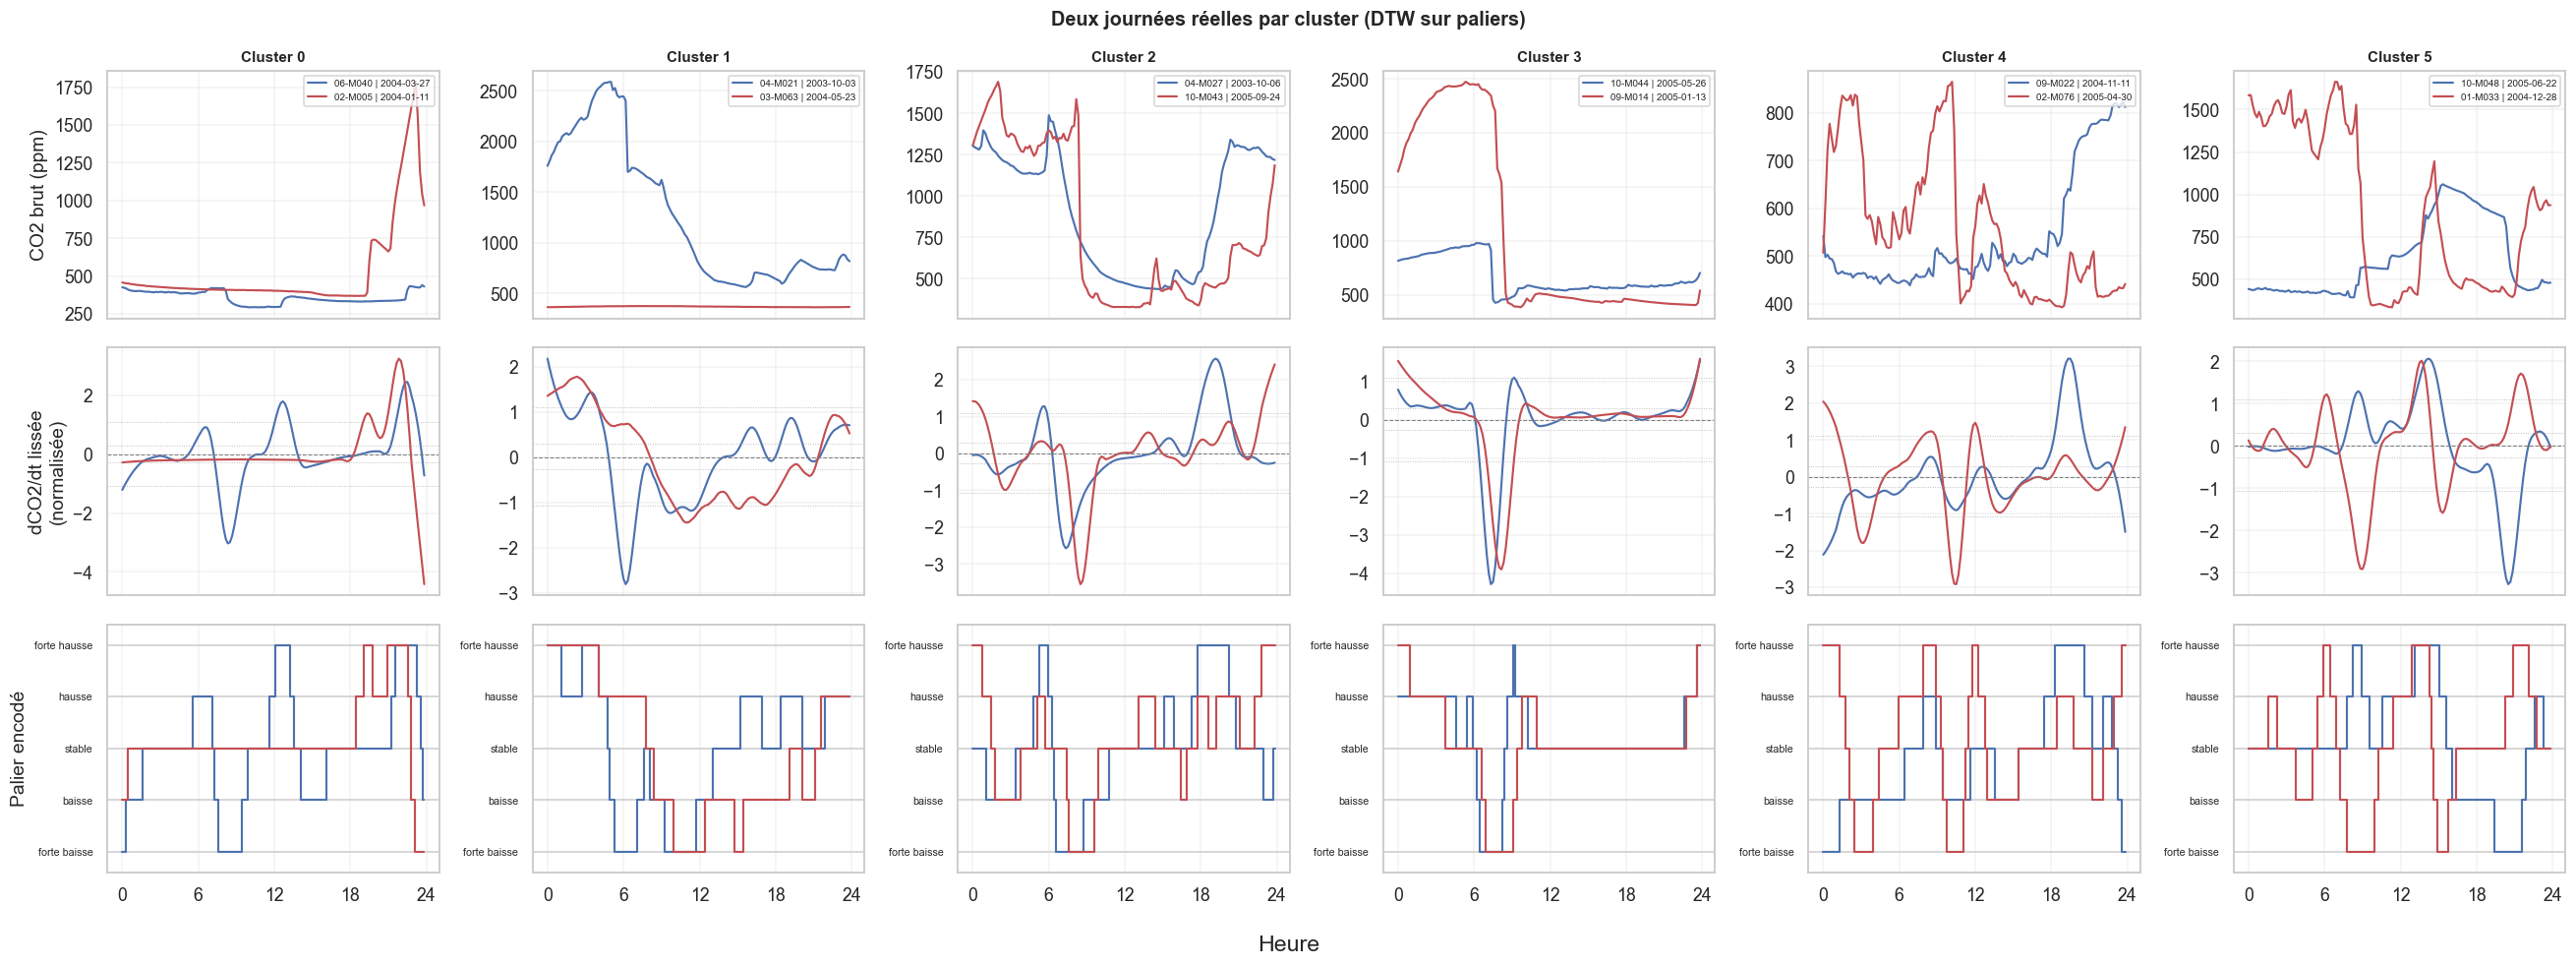

In [12]:
# Journées réelles de chaque cluster DTW : CO2 brut, dérivée normalisée, paliers
EX = pd.concat([d.sample(min(2, len(d)), random_state=42)
                for _, d in meta.groupby('cluster_dtw')])
print('Journées affichées (2 tirées au hasard par cluster DTW) :')
print(EX[['CODELIEU', 'DATE', 'cluster_dtw']].to_string(index=False))

colors = ['#4C72B0', '#C44E52']
fig, axes = plt.subplots(3, K, figsize=(4 * K, 9), sharex=True)

for c in range(K):
    sub_ex = EX[EX['cluster_dtw'] == c]

    ax = axes[0, c]
    for (idx, r), color in zip(sub_ex.iterrows(), colors):
        ax.plot(hours, co2_brut[idx], lw=1.4, color=color,
                label=f"{r['CODELIEU']} | {r['DATE'].date()}")
    ax.set_title(f'Cluster {c}', fontsize=10, fontweight='bold')
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.25)
    ax.legend(fontsize=6.5, loc='upper right')
    if c == 0:
        ax.set_ylabel('CO2 brut (ppm)')

    ax = axes[1, c]
    for (idx, r), color in zip(sub_ex.iterrows(), colors):
        ax.plot(hours, D_lisse[idx], lw=1.4, color=color)
    ax.axhline(0, color='grey', lw=0.7, ls='--')
    for s in seuils:
        ax.axhline(s, color='#999999', lw=0.6, ls=':', alpha=0.7)
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, alpha=0.25)
    if c == 0:
        ax.set_ylabel('dCO2/dt lissée\n(normalisée)')

    ax = axes[2, c]
    for (idx, r), color in zip(sub_ex.iterrows(), colors):
        ax.step(hours, P[idx], where='mid', lw=1.4, color=color)
    ax.set_yticks(range(N_PALIERS)); ax.set_yticklabels(PALIER_NOMS, fontsize=7)
    ax.set_ylim(-0.4, N_PALIERS - 0.6)
    ax.set_xticks([0, 6, 12, 18, 24]); ax.grid(True, axis='x', alpha=0.25)
    if c == 0:
        ax.set_ylabel('Palier encodé')

fig.supxlabel('Heure')
plt.suptitle('Deux journées réelles par cluster (DTW sur paliers)',
            fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()


## 6. Caractérisation des clusters

On croise les clusters (partition DTW) avec des variables **indépendantes du
signal CO2** : type de ventilation, puis caractéristiques du logement et des
occupants. Les croisements se font au niveau du **logement**, via son cluster
dominant, pour qu'un logement longuement observé ne pèse pas plusieurs fois.


In [13]:
val = meta.copy()
val['aeration'] = val['CODELIEU'].map(ventilation)

ct = pd.crosstab(val['cluster_dtw'], val['aeration'], normalize='index').mul(100).round(1)
display(ct.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}%')
        .set_caption('Type de ventilation par cluster (% des journées)'))

log_dom = val.groupby('CODELIEU')['cluster_dtw'].agg(lambda x: x.value_counts().idxmax())
log_aer = val.groupby('CODELIEU')['aeration'].first()

ct_log = pd.crosstab(log_dom, log_aer, normalize='index').mul(100).round(1)
display(ct_log.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.1f}%')
        .set_caption('Type de ventilation par cluster dominant (1 ligne = 1 logement)'))

print(f'{len(log_dom)} logements rattachés à un cluster dominant')


aeration,Aucune,Extracteurs,Naturelle,VMC
cluster_dtw,,,,
0,21.0%,5.5%,38.7%,34.9%
1,18.2%,8.9%,30.3%,42.6%
2,17.8%,10.6%,32.8%,38.8%
3,19.6%,9.8%,29.5%,41.1%
4,28.2%,9.2%,37.6%,25.0%
5,22.4%,12.6%,30.3%,34.6%


aeration,Aucune,Extracteurs,Naturelle,VMC
cluster_dtw,,,,
0,17.9%,3.6%,39.3%,39.3%
1,17.7%,8.8%,31.9%,41.6%
2,17.9%,6.4%,37.2%,38.5%
3,18.9%,12.1%,26.8%,42.1%
4,37.1%,5.7%,41.4%,15.7%
5,11.8%,14.7%,35.3%,38.2%


513 logements rattachés à un cluster dominant


In [14]:
FC3_LABELS = {
    1: 'Maison individuelle', 2: 'Appart. (collectif)', 3: 'Studio (collectif)',
    4: 'Pièce indépendante', 5: 'Logement-foyer', 6: 'Ferme / bât. agricole',
    7: 'Chambre hôtel', 8: 'Construction provisoire', 9: 'Immeuble à usage pro',
}
STRMEN_LABELS = {1: 'Personne seule', 2: 'Famille monoparentale',
                 3: 'Couple', 4: 'Autre ménage'}
INDT_LABELS = {'1': 'Travaille', '2': 'Étudiant', '3': 'Ne travaille pas'}

q_men = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'FC3', 'STRMEN', 'HSRF', 'NPP']).set_index('CODELIEU')
q_men['type_logement']    = pd.to_numeric(q_men['FC3'], errors='coerce').map(FC3_LABELS)
q_men['structure_menage'] = pd.to_numeric(q_men['STRMEN'], errors='coerce').map(STRMEN_LABELS)
q_men['surface']          = pd.to_numeric(q_men['HSRF'], errors='coerce')
q_men['nb_pieces']        = pd.to_numeric(q_men['NPP'], errors='coerce')

q_ind = pd.read_csv(f'{DATA}/Questionnaires_Comportement/CNL1_Q_INDIVIDU_DATA.csv',
                    sep=';', encoding='latin1',
                    usecols=['CODELIEU', 'NUM_OCCUPANT', 'INDT'], dtype={'INDT': str})
q_ind['statut_pro'] = q_ind['INDT'].map(INDT_LABELS).fillna('Non renseigné / enfant')
q_ind['cluster'] = q_ind['CODELIEU'].map(log_dom)

car = pd.DataFrame({'cluster': log_dom}).join(
    q_men[['type_logement', 'structure_menage', 'surface', 'nb_pieces']])
car['nb_occupants'] = car.index.map(q_ind.groupby('CODELIEU')['NUM_OCCUPANT'].nunique())
car['au_moins_un_actif'] = car.index.map(
    q_ind.groupby('CODELIEU')['INDT'].apply(lambda s: (s == '1').any()))

print(f"{len(car)} logements — {car['surface'].notna().sum()} avec surface renseignée, "
      f"{q_ind['cluster'].notna().sum()}/{len(q_ind)} occupants rattachés")


513 logements — 505 avec surface renseignée, 1473/1612 occupants rattachés


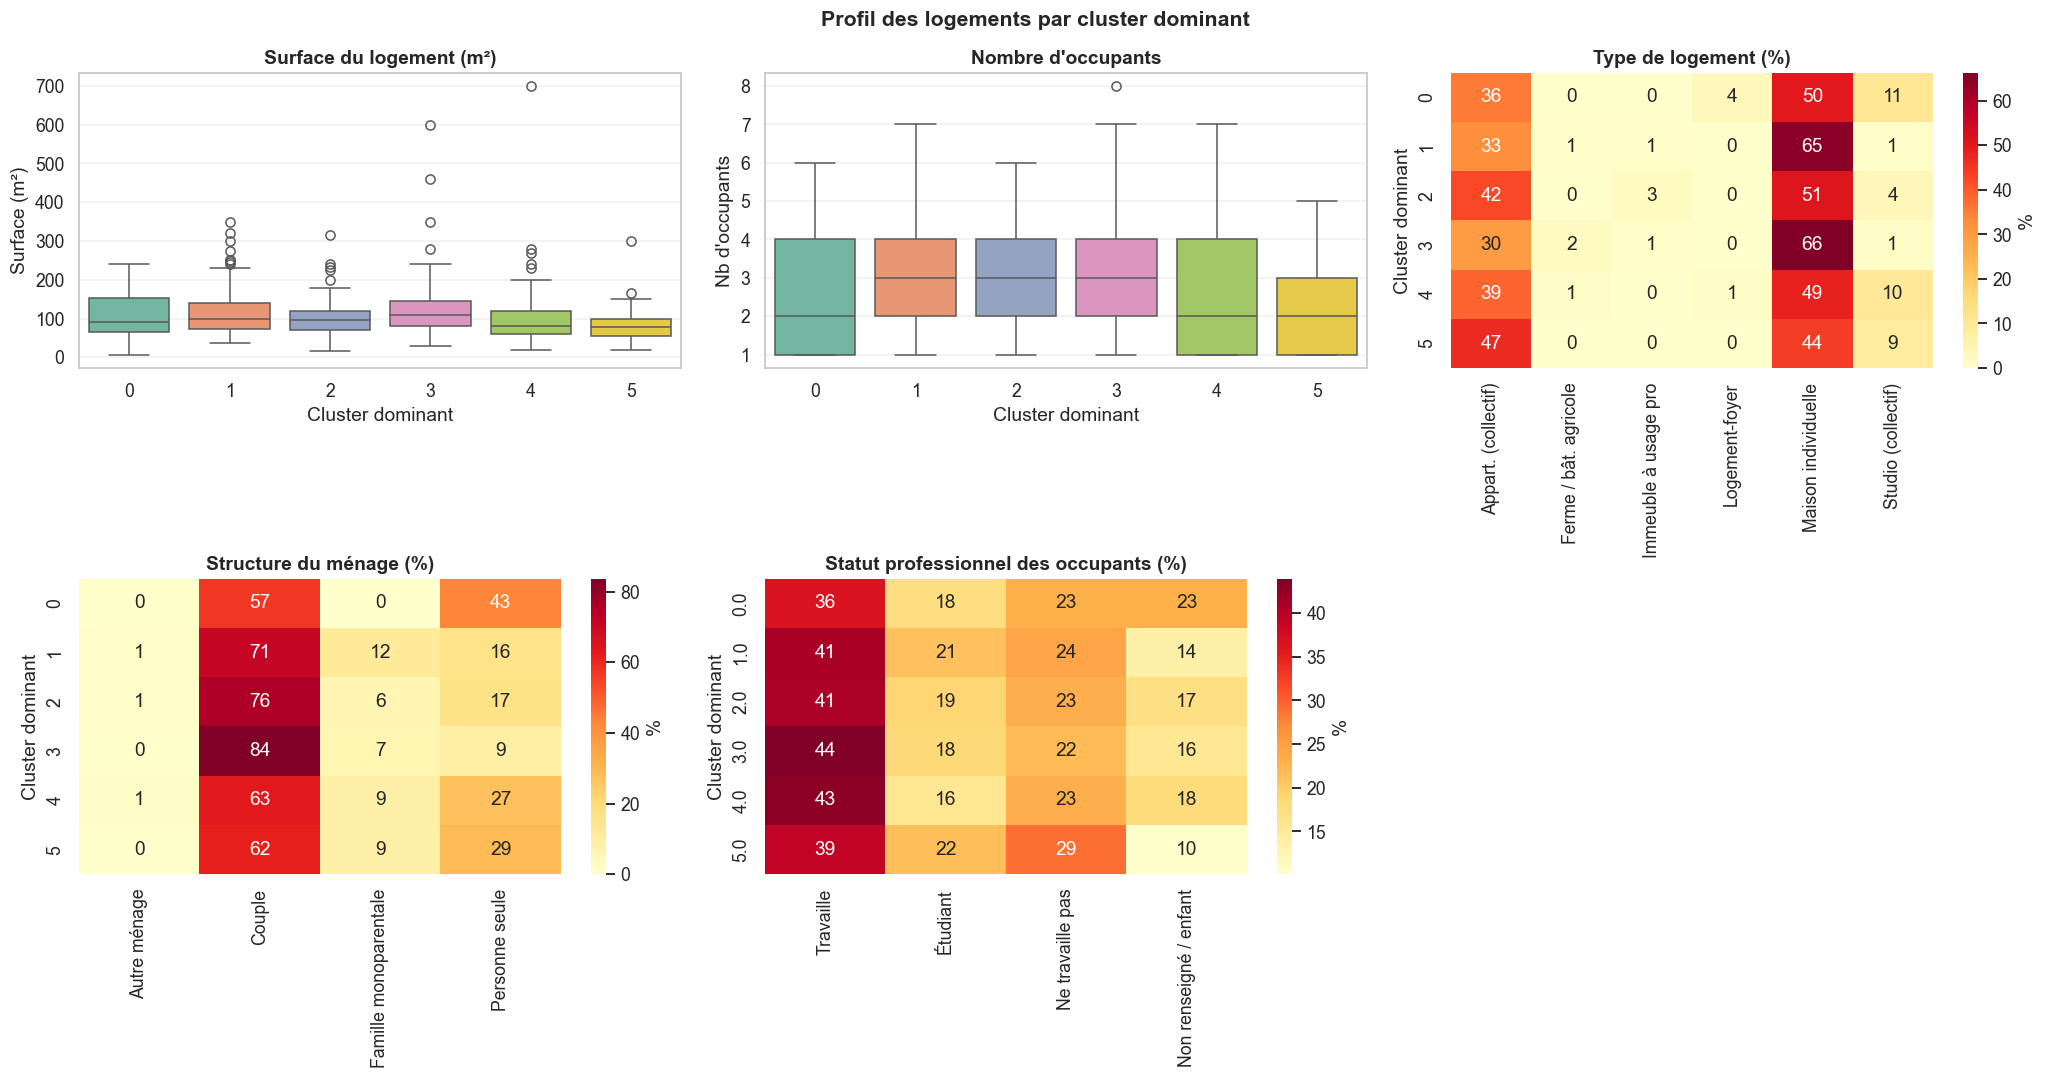

,n_logements,surface_mediane,nb_pieces_median,nb_occupants_median,pct_avec_actif
cluster,,,,,
0,28,91.0,4.0,2.0,67.9
1,113,98.0,4.0,3.0,77.9
2,78,95.0,4.0,3.0,73.1
3,190,110.0,4.0,3.0,77.9
4,70,80.0,3.0,2.0,67.1
5,34,78.0,3.0,2.0,64.7


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

ax = axes[0, 0]
sns.boxplot(data=car.dropna(subset=['surface']), x='cluster', y='surface',
           hue='cluster', palette='Set2', legend=False, ax=ax)
ax.set_title('Surface du logement (m²)', fontweight='bold')
ax.set_xlabel('Cluster dominant'); ax.set_ylabel('Surface (m²)')
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0, 1]
sns.boxplot(data=car.dropna(subset=['nb_occupants']), x='cluster', y='nb_occupants',
           hue='cluster', palette='Set2', legend=False, ax=ax)
ax.set_title("Nombre d'occupants", fontweight='bold')
ax.set_xlabel('Cluster dominant'); ax.set_ylabel("Nb d'occupants")
ax.grid(True, axis='y', alpha=0.3)

ax = axes[0, 2]
sns.heatmap(pd.crosstab(car['cluster'], car['type_logement'], normalize='index').mul(100),
           annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('Type de logement (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

ax = axes[1, 0]
sns.heatmap(pd.crosstab(car['cluster'], car['structure_menage'], normalize='index').mul(100),
           annot=True, fmt='.0f', cmap='YlOrRd', ax=ax, cbar_kws={'label': '%'})
ax.set_title('Structure du ménage (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

ax = axes[1, 1]
ct_statut = pd.crosstab(q_ind['cluster'], q_ind['statut_pro'], normalize='index').mul(100)
ordre = [c for c in ['Travaille', 'Étudiant', 'Ne travaille pas', 'Non renseigné / enfant']
        if c in ct_statut.columns]
sns.heatmap(ct_statut[ordre], annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
           cbar_kws={'label': '%'})
ax.set_title('Statut professionnel des occupants (%)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Cluster dominant')

axes[1, 2].axis('off')
plt.suptitle('Profil des logements par cluster dominant', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

recap = car.groupby('cluster').agg(
    n_logements=('surface', 'size'),
    surface_mediane=('surface', 'median'),
    nb_pieces_median=('nb_pieces', 'median'),
    nb_occupants_median=('nb_occupants', 'median'),
    pct_avec_actif=('au_moins_un_actif', lambda s: 100 * s.mean()),
)
display(recap.round(1))


## 7. Synthèse

À compléter après lecture des résultats :

- **Qualité de l'encodage** — les séquences de paliers restent-elles stables
  (peu de transitions parasites) et fidèles au signal continu ?
- **Description des clusters** — une phrase par cluster : enchaînement type des
  paliers au fil de la journée, et profil d'occupants associé.
- **DTW vs K-means** — l'ARI mesure leur accord ; si les partitions sont très
  proches, la tolérance au décalage n'apporte pas grand-chose ici et la méthode
  euclidienne, bien plus rapide, suffit.
- **Comparaison avec le clustering sur signal continu** (`clustering_journees.ipynb`)
  — la discrétisation fait-elle perdre de l'information utile, ou aboutit-elle à
  des profils comparables et plus lisibles ?
